In [ ]:
!pip install torchinfo opencv-python matplotlib seaborn scikit-learn pandas

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def crop_yolo_data(image_dir, label_dir, output_dir):

    classes = ['Cavity', 'Filling', 'Impacted Tooth', 'Implant']

    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'): continue

        img_name = label_file.replace('.txt', '.jpg')
        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)
        if img is None: continue

        h, w, _ = img.shape

        with open(os.path.join(label_dir, label_file), 'r') as f:
            for line in f.readlines():
                cls, x, y, nw, nh = map(float, line.split())
                class_name = classes[int(cls)]

                x1 = int((x - nw/2) * w)
                y1 = int((y - nh/2) * h)
                x2 = int((x + nw/2) * w)
                y2 = int((y + nh/2) * h)

                crop = img[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]

                save_path = os.path.join(output_dir, class_name)
                os.makedirs(save_path, exist_ok=True)
                cv2.imwrite(os.path.join(save_path, f"crop_{img_name}"), crop)

print("transforming dataset")

transforming dataset


In [ ]:
!unzip /content/processed_data.zip -d /content/

Archive:  /content/processed_data.zip
   creating: /content/data/processed/
   creating: /content/data/processed/test/
   creating: /content/data/processed/test/labels/
  inflating: /content/data/processed/test/labels/0352_jpg.rf.bf5c00a78cd11d9312b4a5c186c29543.txt  
  inflating: /content/data/processed/test/labels/0793_jpg.rf.d3b0af9a1ff2e0c16dfa570a75af7838.txt  
  inflating: /content/data/processed/test/labels/0546_jpg.rf.45ec22088ca14939c5a43bab50ff63f3.txt  
  inflating: /content/data/processed/test/labels/0533_jpg.rf.5c7390e3697dadaaffcfe558c8344907.txt  
  inflating: /content/data/processed/test/labels/0954_jpg.rf.90af42ee301f44eeab572787b14b93e8.txt  
  inflating: /content/data/processed/test/labels/0393_jpg.rf.2bac1ede908463febe81b15ab56fcd79.txt  
  inflating: /content/data/processed/test/labels/0071_jpg.rf.b1ba34e4ca66c958638e8a0041b64a4c.txt  
  inflating: /content/data/processed/test/labels/0281_jpg.rf.0c6592e75ea6229f06fbb6936b4179d0.txt  
  inflating: /content/data/proc

In [ ]:
train_img_dir = '/content/data/processed/train/images'
train_lbl_dir = '/content/data/processed/train/labels'

valid_img_dir = '/content/data/processed/valid/images'
valid_lbl_dir = '/content/data/processed/valid/labels'

out_train_dir = '/content/Classification_Dataset/train'
out_valid_dir = '/content/Classification_Dataset/valid'

crop_yolo_data(train_img_dir, train_lbl_dir, out_train_dir)

crop_yolo_data(valid_img_dir, valid_lbl_dir, out_valid_dir)

print("croping images done")

croping images done


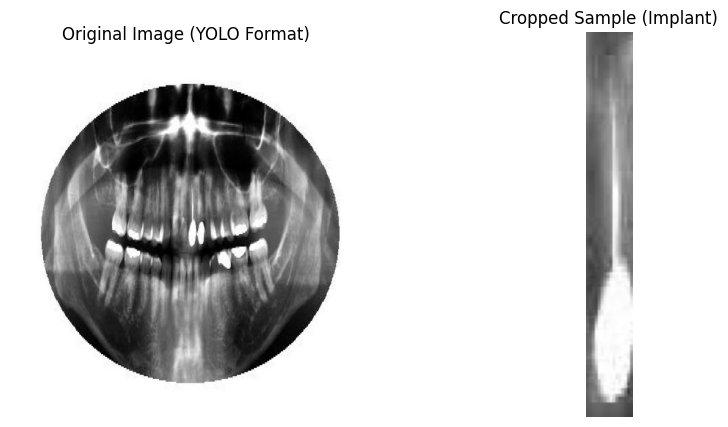

In [ ]:
def visualize_sample():
    train_dir = '/content/Classification_Dataset/train'
    classes = os.listdir(train_dir)
    selected_class = random.choice(classes)
    class_path = os.path.join(train_dir, selected_class)

    crop_name = random.choice(os.listdir(class_path))
    crop_img = cv2.imread(os.path.join(class_path, crop_name))
    crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)

    original_img_name = crop_name.replace('crop_', '')
    original_path = None
    for root, dirs, files in os.walk('/content/data/processed/train'):
        if original_img_name in files:
            original_path = os.path.join(root, original_img_name)
            break

    if original_path:
        orig_img = cv2.imread(original_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(orig_img)
        plt.title('Original Image (YOLO Format)')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(crop_img)
        plt.title(f'Cropped Sample ({selected_class})')
        plt.axis('off')

        plt.show()
    else:
        print("Could not find the original image, but here is the crop:")
        plt.imshow(crop_img)
        plt.axis('off')
        plt.show()

visualize_sample()

In [ ]:
batch_size = 32
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/Classification_Dataset/train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/Classification_Dataset/valid',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data loaded successfully and ready for Keras training!")

Found 3909 files belonging to 4 classes.
Found 447 files belonging to 4 classes.
Data loaded successfully and ready for Keras training!


In [ ]:
def build_dental_model(input_shape=(128, 128, 3), num_classes=4):

    image_input = Input(shape=input_shape)

    x = Conv2D(16, (3, 3), activation="relu", padding="same")(image_input)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=image_input, outputs=output)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])
    return model

dental_model = build_dental_model()
print("Model architecture built successfully!")
dental_model.summary()

Model architecture built successfully!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,380 (8.09 MB)

 Trainable params: 2,121,380 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

Starting the training process...
Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5810 - loss: 0.9706 - val_accuracy: 0.7248 - val_loss: 0.6707
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7600 - loss: 0.6395 - val_accuracy: 0.7584 - val_loss: 0.5615
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8171 - loss: 0.4985 - val_accuracy: 0.7338 - val_loss: 0.5950
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8480 - loss: 0.4018 - val_accuracy: 0.7987 - val_loss: 0.5104
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8739 - loss: 0.3466 - val_accuracy: 0.8479 - val_loss: 0.4376
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8926 - loss: 0.2930 - val_accuracy: 0.8479 - val_loss: 0.4153
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9066 - loss: 0.2582 - val_accuracy: 0.8389 - val_loss: 0.4549
Epoch 8/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy

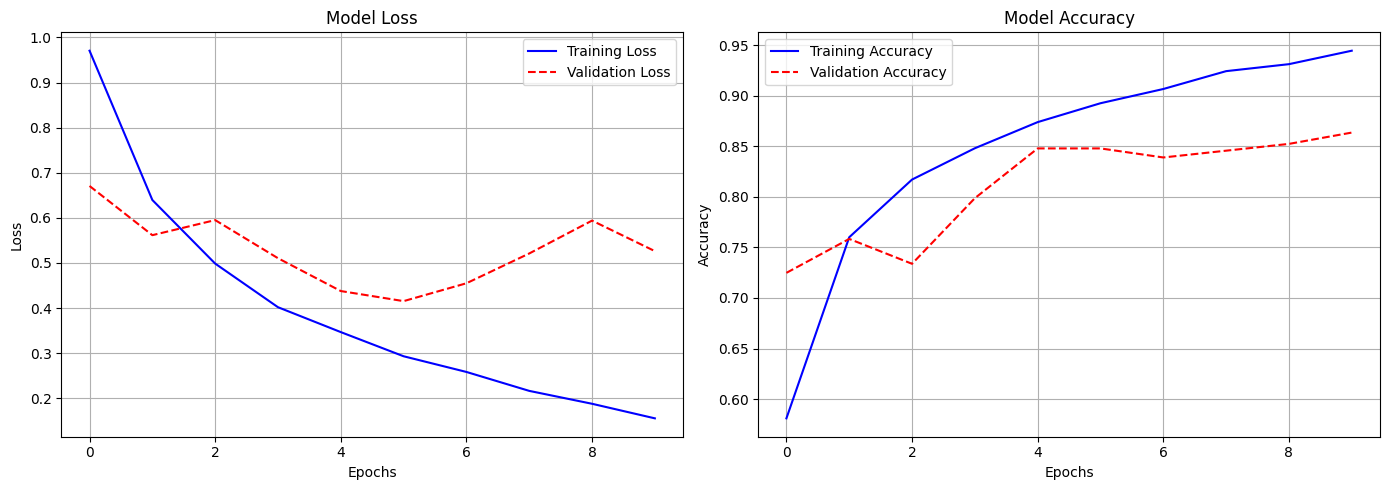

Model saved to 'custom_dental_cnn.h5'


In [ ]:
epochs = 10

print("Starting the training process...")

history = dental_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Training completed! Plotting results...")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', linestyle='dashed')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', linestyle='dashed')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

dental_model.save('custom_dental_cnn.h5')
print("Model saved to 'custom_dental_cnn.h5'")

Evaluating the model...

Classification Report:
                precision    recall  f1-score   support

        Cavity       0.79      0.60      0.68        52
       Filling       0.88      0.87      0.88       193
Impacted Tooth       0.84      0.86      0.85        57
       Implant       0.86      0.95      0.90       145

      accuracy                           0.86       447
     macro avg       0.85      0.82      0.83       447
  weighted avg       0.86      0.86      0.86       447



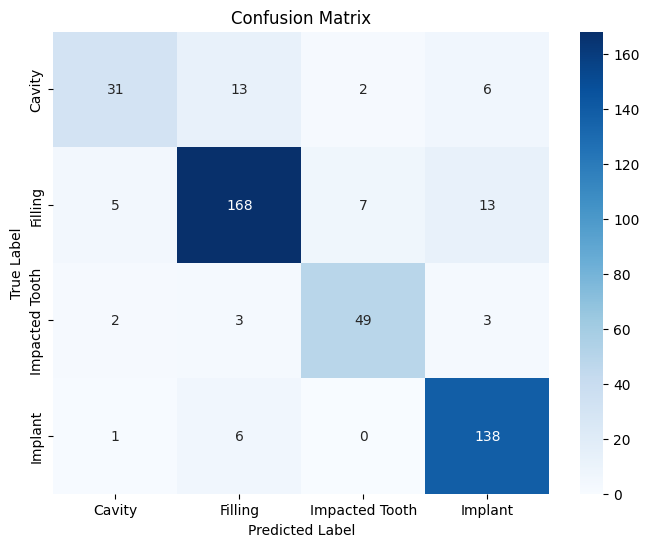

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['Cavity', 'Filling', 'Impacted Tooth', 'Implant']

print("Evaluating the model...")
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.append(labels.numpy())
    y_pred_probs.append(dental_model.predict(images, verbose=0))

y_true = np.concatenate(y_true, axis=0)
y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()